In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import plotly.graph_objects as go

src_path = Path.cwd() / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import dm_spikes as dm

In [2]:
M = 2.6e6
D = 8.5e3
rho0_iso = 0.0062
sigma_v = 100.0
m = 8.963e-56  # Msun
observable_sigma_v = 3.221e-74  # pc^3 / yr
bh_age = 1e10  # yr
R_S = dm.schwarzschild_radius(M)

In [3]:
data = np.load("results/gs_numerical_reconstruction.npz", allow_pickle=True)

r_iso = data["r_iso"]
rho_iso = data["rho_iso"]
gamma_values = data["gamma_values"]
r_cusp_grid = data["r_cusp_grid"]
rho_cusp_grid = data["rho_cusp_grid"]
g_gamma_grid = data["g_gamma_grid"]
dgdr_grid = data["dgdr_grid"]
rho_spike_grid = data["rho_spike_grid"]
R_core_values = data["R_core_values"]
R_sp_values = data["R_sp_values"]

print("Perfiles cargados desde archivo.")
print("r_iso:", r_iso.shape)
print("rho_iso:", rho_iso.shape)
print("gamma_values:", gamma_values.shape)
print("r_cusp_grid:", r_cusp_grid.shape)
print("rho_cusp_grid:", rho_cusp_grid.shape)
print("g_gamma_grid:", g_gamma_grid.shape)
print("dgdr_grid:", dgdr_grid.shape)
print("rho_spike_grid:", rho_spike_grid.shape)
print("R_core_values:", R_core_values.shape)
print("R_sp_values:", R_sp_values.shape)

Perfiles cargados desde archivo.
r_iso: (300,)
rho_iso: (300,)
gamma_values: (195,)
r_cusp_grid: (195, 300)
rho_cusp_grid: (195, 300)
g_gamma_grid: (195, 300)
dgdr_grid: (195, 300)
rho_spike_grid: (195, 300)
R_core_values: (195,)
R_sp_values: (195,)


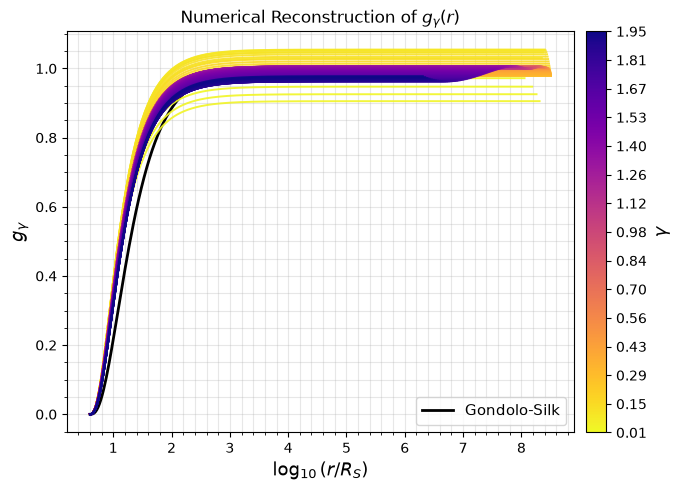

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))

gamma_values = np.asarray(gamma_values, dtype=float)
norm = Normalize(vmin=gamma_values.min(),vmax=gamma_values.max())
cmap = plt.get_cmap("plasma_r")

gs_line, = ax.plot(np.log10(np.logspace(np.log10(4.001 * R_S), np.log10(8.5), 300) / R_S),np.maximum(1.0 - 4.0 * R_S / np.logspace(np.log10(4.001 * R_S), np.log10(8.5), 300), 0.0) ** 3,color="black",lw=2,label="Gondolo-Silk")
for i, gamma_i in enumerate(gamma_values):
    r_cusp_i = r_cusp_grid[i]
    rho_i = rho_cusp_grid[i]

    g_gamma_i = dm.g_gamma(rho_i,r_cusp_i,gamma_i,M=M,D=D)

    valid_mask = (np.isfinite(r_cusp_i) & np.isfinite(rho_i) & np.isfinite(g_gamma_i) & (r_cusp_i > 0) & (rho_i > 0))

    ax.plot(
        np.log10(r_cusp_i[valid_mask] / R_S),
        g_gamma_i[valid_mask],
        color=cmap(norm(gamma_i)),
        lw=1.4,
        alpha=0.9,
    )

colorbar_source = ScalarMappable(norm=norm, cmap=cmap)
colorbar_source.set_array([])

colorbar = fig.colorbar(colorbar_source,ax=ax,pad=0.02,)
colorbar.set_label(r"$\gamma$", fontsize=13)

gamma_ticks = np.linspace(gamma_values.min(),gamma_values.max(),15)
colorbar.set_ticks(gamma_ticks)
colorbar.set_ticklabels([f"{gamma:.2f}" for gamma in gamma_ticks])
ax.legend(handles=[gs_line],loc="lower right",fontsize=11)
ax.set_xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
ax.set_ylabel(r"$g_\gamma$", fontsize=13)
ax.set_title(r"Numerical Reconstruction of $g_\gamma(r)$")
ax.grid(True, which="both", alpha=0.3)
ax.minorticks_on()

fig.tight_layout()
plt.show()

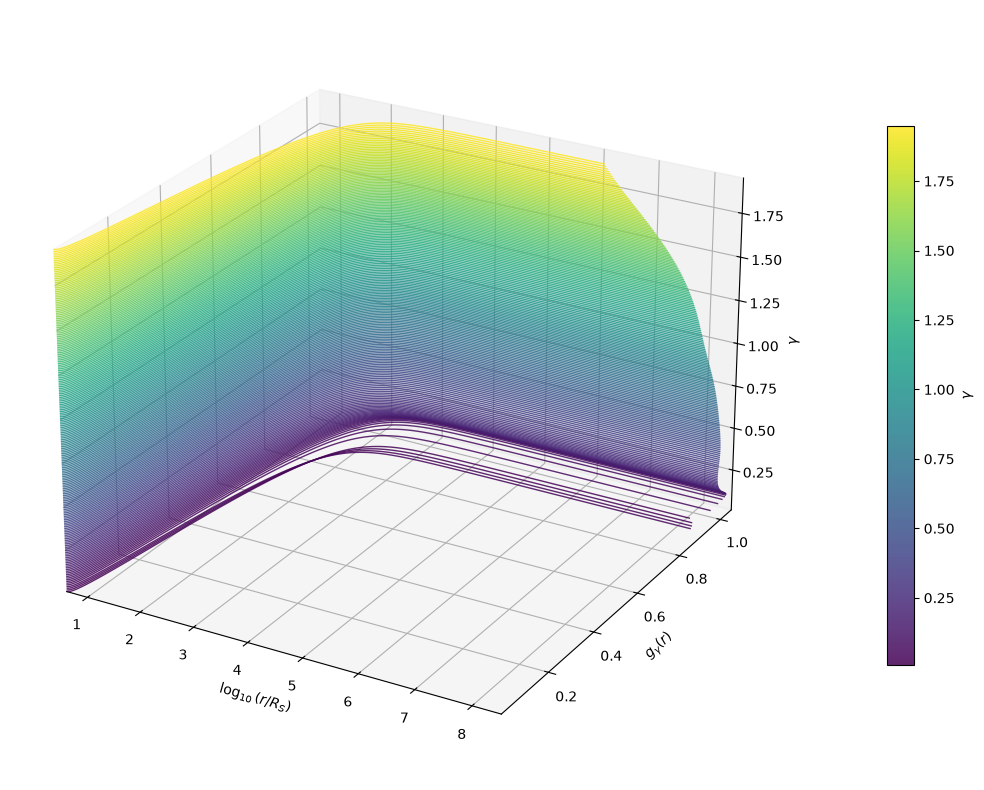

In [5]:
fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection="3d")

curvas = []
gammas_validos = []

for i, gamma in enumerate(gamma_values):
    r = r_cusp_grid[i]
    g = g_gamma_grid[i]

    mascara = (
        np.isfinite(r)
        & np.isfinite(g)
        & (r > 0)
    )

    # Usamos log10(r/R_S) porque el intervalo radial es muy grande.
    x = np.log10(r[mascara] / R_S)
    y = g[mascara]
    z = np.full_like(x, gamma)

    curvas.append(np.column_stack((x, y, z)))
    gammas_validos.append(gamma)

norm = Normalize(
    vmin=np.min(gammas_validos),
    vmax=np.max(gammas_validos),
)

coleccion = Line3DCollection(
    curvas,
    cmap="viridis",
    norm=norm,
    linewidth=1.0,
    alpha=0.85,
)

coleccion.set_array(np.asarray(gammas_validos))
ax.add_collection3d(coleccion)

# Line3DCollection no ajusta automáticamente los límites.
todos_los_puntos = np.concatenate(curvas)

ax.set_xlim(todos_los_puntos[:, 0].min(), todos_los_puntos[:, 0].max())
ax.set_ylim(todos_los_puntos[:, 1].min(), todos_los_puntos[:, 1].max())
ax.set_zlim(np.min(gammas_validos), np.max(gammas_validos))

ax.set_xlabel(r"$\log_{10}(r/R_S)$")
ax.set_ylabel(r"$g_\gamma(r)$")
ax.set_zlabel(r"$\gamma$")

ax.view_init(elev=25, azim=-60)

cbar = fig.colorbar(coleccion, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label(r"$\gamma$")

plt.tight_layout()
plt.show()

In [4]:
x_plot = []
y_plot = []
z_plot = []
color_plot = []

max_puntos_por_curva = 600

for i, gamma in enumerate(gamma_values):
    r = np.asarray(r_cusp_grid[i])
    g = np.asarray(g_gamma_grid[i])

    indices = np.flatnonzero(
        np.isfinite(r)
        & np.isfinite(g)
        & (r > 0)
    )

    # Reduce únicamente el número de puntos, no el número de funciones.
    if indices.size > max_puntos_por_curva:
        seleccion = np.linspace(
            0,
            indices.size - 1,
            max_puntos_por_curva,
            dtype=int,
        )
        indices = indices[seleccion]

    x = np.log10(r[indices] / R_S)
    y = g[indices]
    z = np.full(x.shape, gamma)

    # None separa las curvas para que Plotly no las conecte.
    x_plot.extend(x.tolist() + [None])
    y_plot.extend(y.tolist() + [None])
    z_plot.extend(z.tolist() + [None])
    color_plot.extend([gamma] * (len(x) + 1))

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=x_plot,
            y=y_plot,
            z=z_plot,
            mode="lines",
            line=dict(
                color=color_plot,
                colorscale="Viridis",
                width=3,
                colorbar=dict(title=r"gamma"),
            ),
            hovertemplate=(
                "log10(r/Rs) = %{x:.4f}<br>"
                "g = %{y:.6g}<br>"
                "gamma = %{z:.4f}"
                "<extra></extra>"
            ),
        )
    ]
)

fig.update_layout(
    width=850,
    height=700,
    scene=dict(
        xaxis_title="log10(r / R_S)",
        yaxis_title="g_gamma(r)",
        zaxis_title="gamma",
        aspectmode="manual",
        aspectratio=dict(x=1.5, y=1.0, z=1.0),
        camera=dict(eye=dict(x=1.5, y=-1.5, z=1.0)),
        dragmode="orbit",
    ),
    margin=dict(l=0, r=0, b=0, t=30),
)

fig.show()

In [6]:
def g_fit_directo(r, gamma, R_S):
    """Ajuste global explicito de g_gamma(r)."""
    r = np.asarray(r, dtype=float)
    gamma = np.asarray(gamma, dtype=float)
    r, gamma = np.broadcast_arrays(r, gamma)

    gamma_hat = (gamma - 0.98) / 0.97

    A = np.exp(0.015111398608519715)

    B = np.exp(
        0.8815044083943646
        + 0.04600386809356462 * gamma_hat
        + 0.008627176525459907 * (2.0 * gamma_hat**2 - 1.0)
    )

    with np.errstate(divide="ignore", invalid="ignore"):
        x = 1.0 - 4.0 * R_S / r

    resultado = np.zeros_like(x, dtype=float)
    mascara = np.isfinite(x) & np.isfinite(B) & (x > 0.0)
    resultado[mascara] = A * x[mascara] ** B[mascara]

    return resultado


x_num, y_num, z_num, colores = [], [], [], []
x_fit, y_fit, z_fit = [], [], []

for i, gamma in enumerate(gamma_values):
    r = np.asarray(r_cusp_grid[i], dtype=float)
    g = np.asarray(g_gamma_grid[i], dtype=float)

    mascara = np.isfinite(r) & np.isfinite(g) & (r > 4.0 * R_S)
    r_valido = r[mascara]

    x = np.log10(r_valido / R_S)
    z = np.full_like(x, gamma)
    g_ajustado = g_fit_directo(r_valido, gamma, R_S)

    x_num.extend(x.tolist() + [None])
    y_num.extend(g[mascara].tolist() + [None])
    z_num.extend(z.tolist() + [None])
    colores.extend([gamma] * (len(x) + 1))

    x_fit.extend(x.tolist() + [None])
    y_fit.extend(g_ajustado.tolist() + [None])
    z_fit.extend(z.tolist() + [None])

fig = go.Figure()

fig.add_trace(
    go.Scatter3d(
        x=x_num,
        y=y_num,
        z=z_num,
        mode="lines",
        name="Reconstruccion numerica",
        line=dict(
            color=colores,
            colorscale="Viridis",
            width=3,
            colorbar=dict(title="gamma"),
        ),
        opacity=0.65,
        hovertemplate=(
            "Numerico<br>"
            "log10(r/R_S) = %{x:.4f}<br>"
            "g = %{y:.6g}<br>"
            "gamma = %{z:.4f}<extra></extra>"
        ),
    )
)

fig.add_trace(
    go.Scatter3d(
        x=x_fit,
        y=y_fit,
        z=z_fit,
        mode="lines",
        name="Ajuste global",
        line=dict(color="red", width=0.5),
        opacity=0.9,
        hovertemplate=(
            "Ajuste<br>"
            "log10(r/R_S) = %{x:.4f}<br>"
            "g_fit = %{y:.6g}<br>"
            "gamma = %{z:.4f}<extra></extra>"
        ),
    )
)

fig.update_layout(
    title="Reconstruccion numerica y ajuste global",
    width=700,
    height=550,
    scene=dict(
        xaxis_title="log10(r/R_S)",
        yaxis_title="g_gamma(r)",
        zaxis_title="gamma",
        aspectmode="manual",
        aspectratio=dict(x=1.5, y=1, z=1),
        camera=dict(eye=dict(x=1.5, y=-1.5, z=1)),
        dragmode="orbit",
    ),
    margin=dict(l=0, r=0, b=0, t=45),
)

fig.show()